<a href="https://colab.research.google.com/github/morozovsolncev/gravitation/blob/main/quantum_gravity_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

КОНСТАНТЫ
G         = 6.674e-11 м³/кг/с²
c         = 2.998e+08 м/с
ħ         = 1.055e-34 Дж·с
M_p       = 2.176e-08 кг (0.0 г)
l_p       = 1.616e-35 м (1.62·10⁻³⁵ м)
k         = 1.485e-27 м/кг
k·M_p     = 3.233e-35 м (должно быть ~ l_p/2?)


ИССЛЕДОВАНИЕ РЕГУЛЯРИЗУЮЩИХ ФУНКЦИЙ
Онтология синтеза, 2026

СРАВНЕНИЕ ДЛЯ МАССЫ протон: M = 1.673e-27 кг


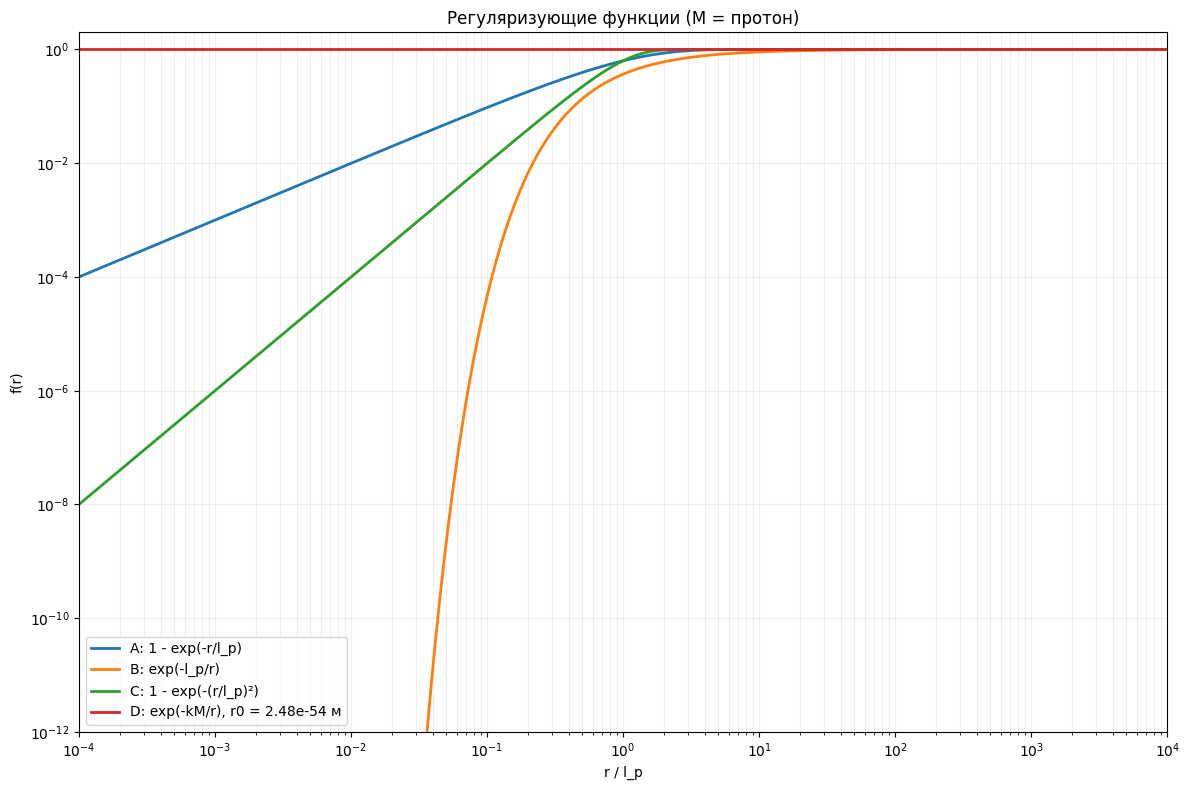

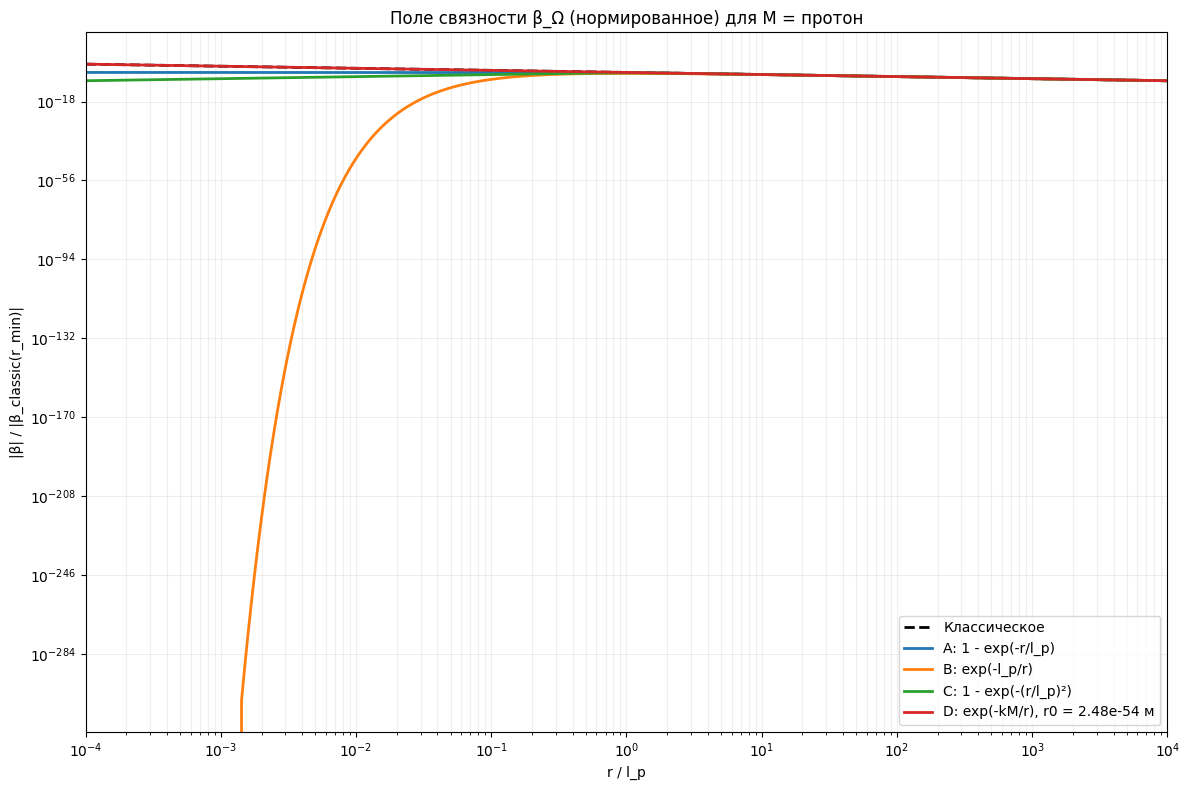

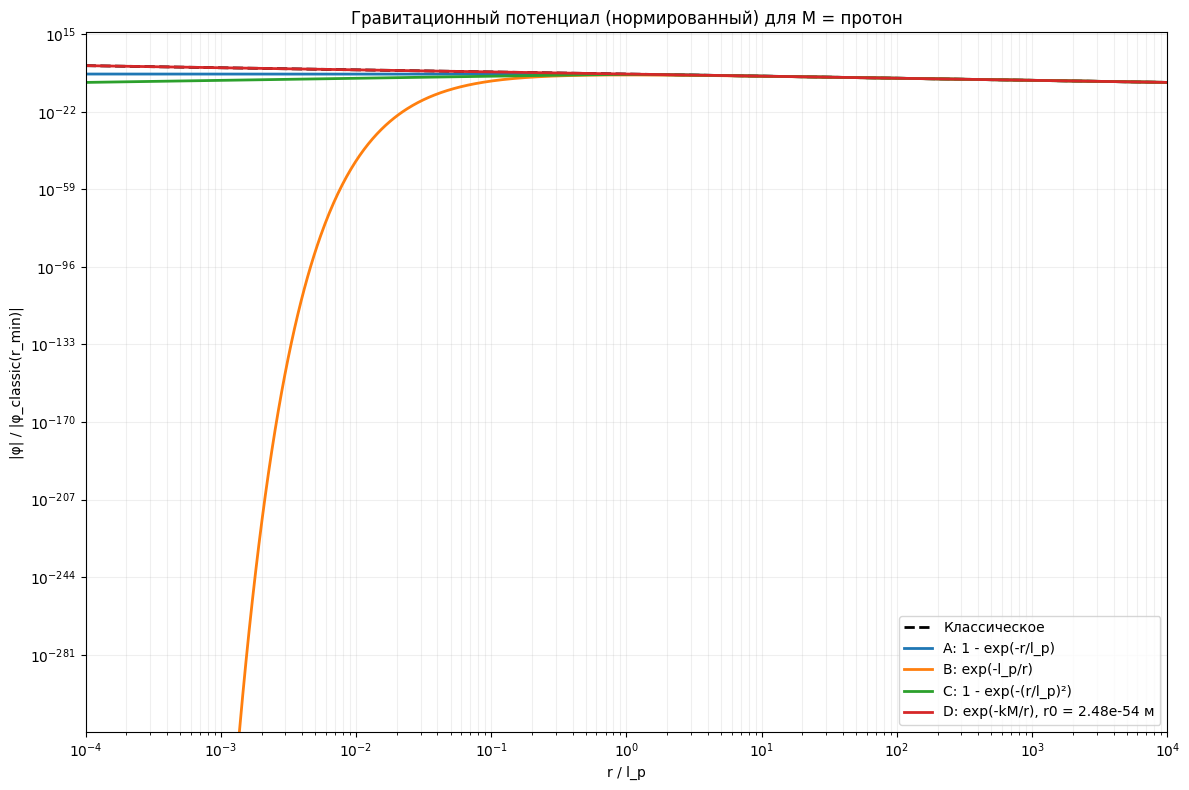


ХАРАКТЕРИСТИКИ НА ПЛАНКОВСКОМ МАСШТАБЕ (r = l_p):
--------------------------------------------------
A: 1 - exp(-r/l_p):
  f(l_p) = 6.321e-01
  β(l_p) = -9.716e-20
  φ(l_p) = -4.366e-03 м²/с²
B: exp(-l_p/r):
  f(l_p) = 3.679e-01
  β(l_p) = -5.654e-20
  φ(l_p) = -2.541e-03 м²/с²
C: 1 - exp(-(r/l_p)²):
  f(l_p) = 6.321e-01
  β(l_p) = -9.716e-20
  φ(l_p) = -4.366e-03 м²/с²
D: exp(-kM/r), r0 = 2.48e-54 м:
  f(l_p) = 1.000e+00
  β(l_p) = -1.537e-19
  φ(l_p) = -6.907e-03 м²/с²

Характерный радиус регулятора D: r0 = 2.484e-54 м = 0.000 l_p

СРАВНЕНИЕ ДЛЯ МАССЫ планковская масса: M = 2.176e-08 кг


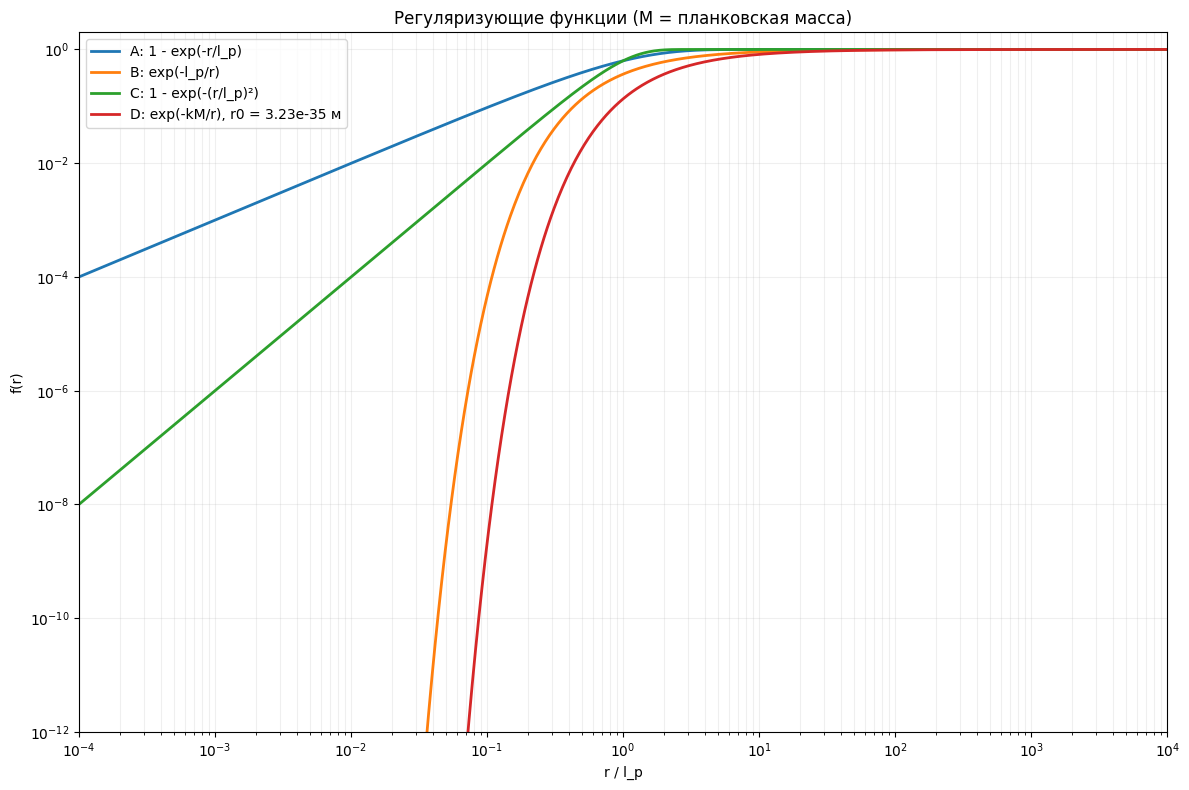

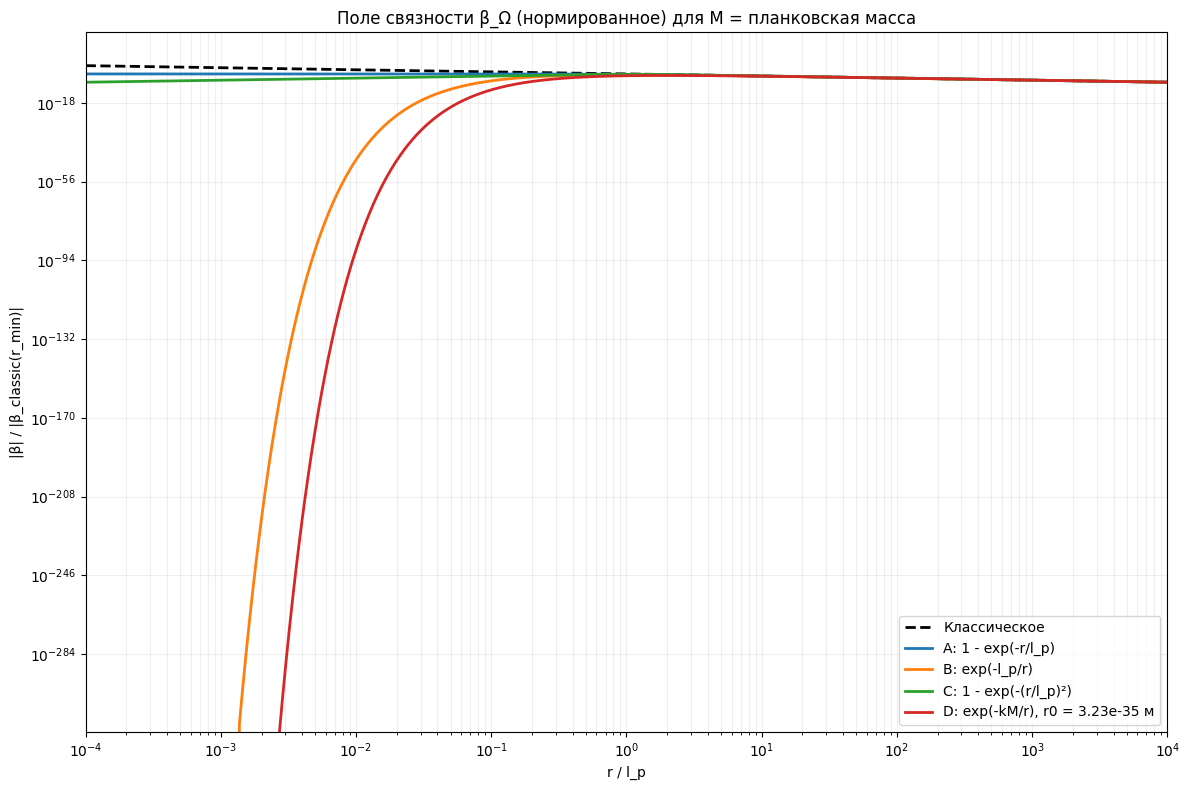

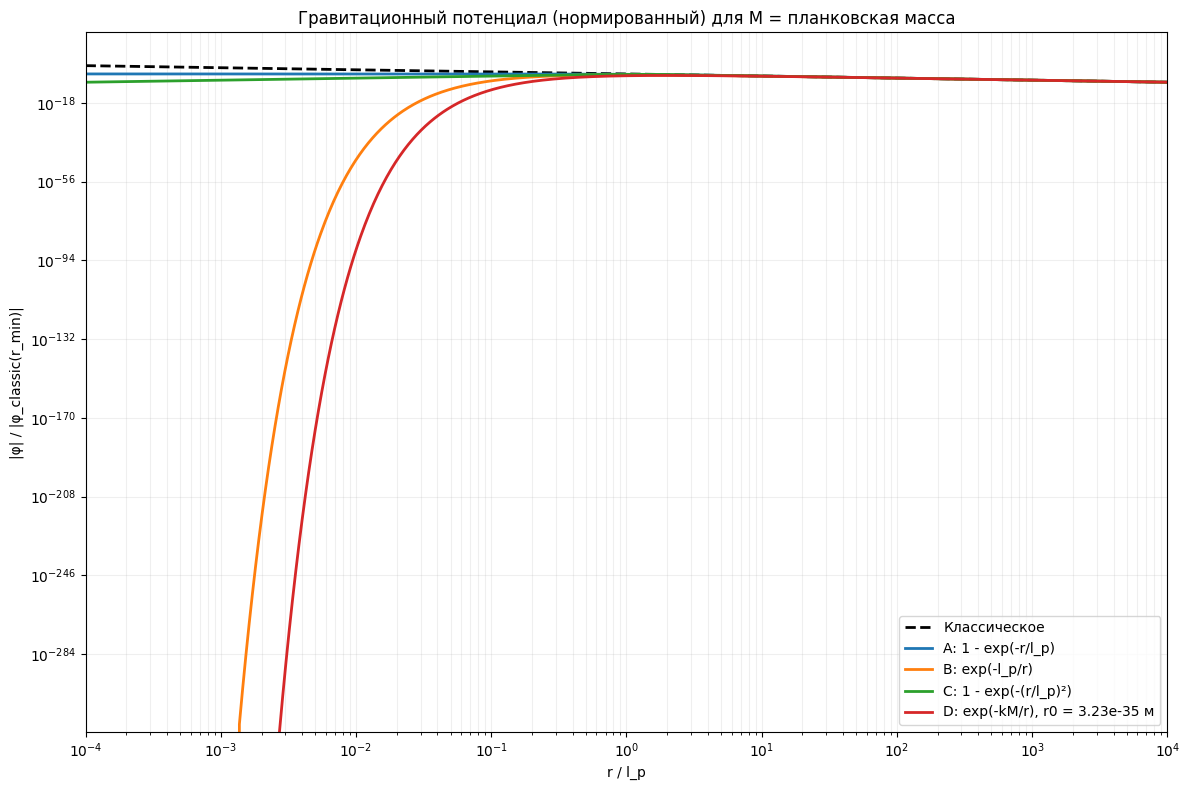


ХАРАКТЕРИСТИКИ НА ПЛАНКОВСКОМ МАСШТАБЕ (r = l_p):
--------------------------------------------------
A: 1 - exp(-r/l_p):
  f(l_p) = 6.321e-01
  β(l_p) = -1.264e+00
  φ(l_p) = -5.681e+16 м²/с²
B: exp(-l_p/r):
  f(l_p) = 3.679e-01
  β(l_p) = -7.358e-01
  φ(l_p) = -3.306e+16 м²/с²
C: 1 - exp(-(r/l_p)²):
  f(l_p) = 6.321e-01
  β(l_p) = -1.264e+00
  φ(l_p) = -5.681e+16 м²/с²
D: exp(-kM/r), r0 = 3.23e-35 м:
  f(l_p) = 1.353e-01
  β(l_p) = -2.707e-01
  φ(l_p) = -1.216e+16 м²/с²

Характерный радиус регулятора D: r0 = 3.233e-35 м = 2.000 l_p

СРАВНЕНИЕ ДЛЯ МАССЫ 10 M_p: M = 2.176e-07 кг


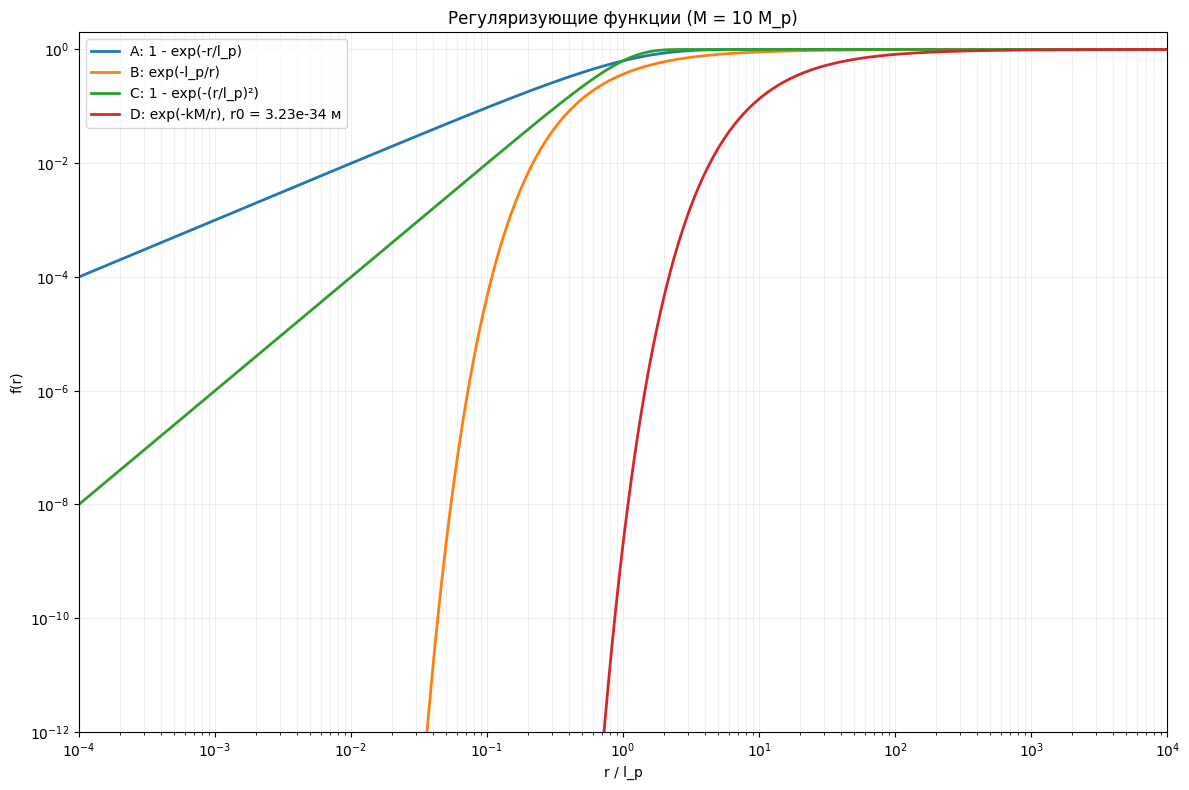

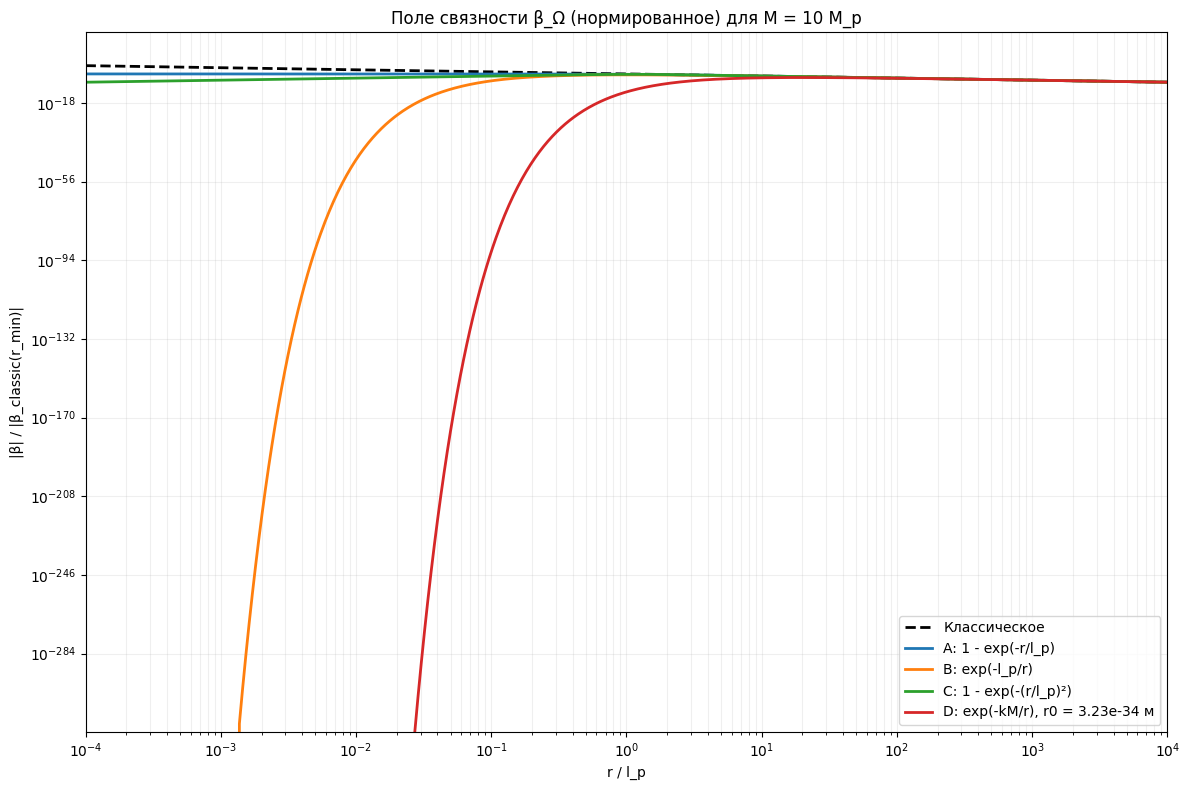

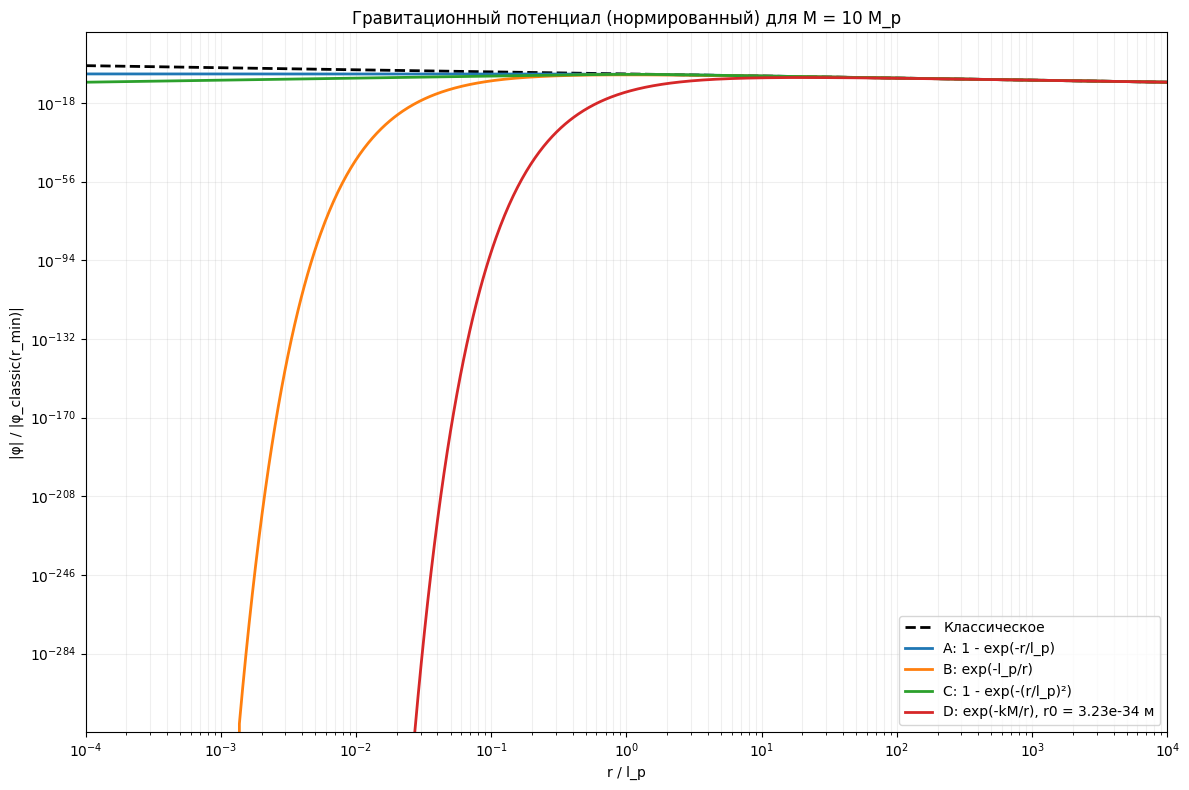


ХАРАКТЕРИСТИКИ НА ПЛАНКОВСКОМ МАСШТАБЕ (r = l_p):
--------------------------------------------------
A: 1 - exp(-r/l_p):
  f(l_p) = 6.321e-01
  β(l_p) = -1.264e+01
  φ(l_p) = -5.681e+17 м²/с²
B: exp(-l_p/r):
  f(l_p) = 3.679e-01
  β(l_p) = -7.358e+00
  φ(l_p) = -3.306e+17 м²/с²
C: 1 - exp(-(r/l_p)²):
  f(l_p) = 6.321e-01
  β(l_p) = -1.264e+01
  φ(l_p) = -5.681e+17 м²/с²
D: exp(-kM/r), r0 = 3.23e-34 м:
  f(l_p) = 2.061e-09
  β(l_p) = -4.122e-08
  φ(l_p) = -1.852e+09 м²/с²

Характерный радиус регулятора D: r0 = 3.233e-34 м = 20.000 l_p

СКАНИРОВАНИЕ ПО МАССЕ

ЗНАЧЕНИЯ РЕГУЛЯТОРА D ПРИ r = l_p:
------------------------------------------------------------
      Масса, кг |      M/M_p |     D_Ω(l_p) |     f_D(l_p)
------------------------------------------------------------
      1.000e-30 |  4.595e-23 |    9.189e-23 |    1.000e+00
      2.176e-23 |  1.000e-15 |    2.000e-15 |    1.000e+00
      2.176e-11 |  1.000e-03 |    2.000e-03 |    9.980e-01
      2.176e-08 |  1.000e+00 |    2.000e+0

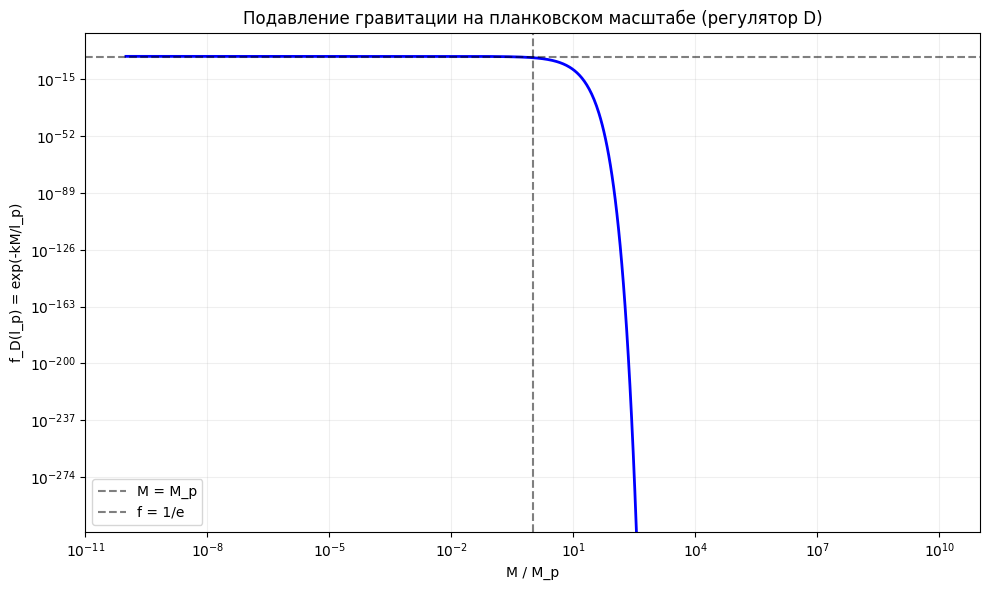


РАСЧЁТ ЗАВЕРШЁН


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Исследование регуляризующих функций для поля связности β_Ω
в рамках Онтологии синтеза.

Сравниваются четыре кандидата:
A: f(x) = 1 - exp(-x)
B: f(x) = exp(-1/x)
C: f(x) = 1 - exp(-x²)
D: f(r) = exp(-D_Ω), где D_Ω = kM/r (онтологическое расстояние)

Автор: Онтология синтеза, 2026
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

# ====================================================================
# ФИЗИЧЕСКИЕ КОНСТАНТЫ (СИ)
# ====================================================================
G = 6.67430e-11          # гравитационная постоянная, м³/кг/с²
c = 299792458            # скорость света, м/с
hbar = 1.0545718e-34     # постоянная Планка, Дж·с

# Планковские единицы
M_planck = np.sqrt(hbar * c / G)      # планковская масса, кг
l_planck = np.sqrt(hbar * G / c**3)   # планковская длина, м
t_planck = np.sqrt(hbar * G / c**5)   # планковское время, с

# Онтологические константы
k = 2 * G / c**2          # константа связи, м/кг
eta = c**2                # константа перевода, м²/с²

print("=" * 60)
print("КОНСТАНТЫ")
print("=" * 60)
print(f"G         = {G:.3e} м³/кг/с²")
print(f"c         = {c:.3e} м/с")
print(f"ħ         = {hbar:.3e} Дж·с")
print(f"M_p       = {M_planck:.3e} кг ({M_planck/1e-3:.1f} г)")
print(f"l_p       = {l_planck:.3e} м ({l_planck*1e35:.2f}·10⁻³⁵ м)")
print(f"k         = {k:.3e} м/кг")
print(f"k·M_p     = {k * M_planck:.3e} м (должно быть ~ l_p/2?)")
print()

# ====================================================================
# КЛАССЫ РЕГУЛЯТОРОВ
# ====================================================================

class RegulatorA:
    """f(x) = 1 - exp(-x), x = r/l_p"""
    def __init__(self, l_planck):
        self.l_p = l_planck
        self.name = "A: 1 - exp(-r/l_p)"

    def __call__(self, r):
        x = r / self.l_p
        return 1 - np.exp(-x)

    def get_scale(self):
        return self.l_p


class RegulatorB:
    """f(x) = exp(-1/x), x = r/l_p"""
    def __init__(self, l_planck):
        self.l_p = l_planck
        self.name = "B: exp(-l_p/r)"

    def __call__(self, r):
        # Безопасное вычисление: при r -> 0 результат -> 0
        if np.isscalar(r):
            if r < 1e-40:
                return 0.0
            return np.exp(-self.l_p / r)
        else:
            result = np.zeros_like(r)
            mask = r > 1e-40
            result[mask] = np.exp(-self.l_p / r[mask])
            return result

    def get_scale(self):
        return self.l_p


class RegulatorC:
    """f(x) = 1 - exp(-x²), x = r/l_p"""
    def __init__(self, l_planck):
        self.l_p = l_planck
        self.name = "C: 1 - exp(-(r/l_p)²)"

    def __call__(self, r):
        x = r / self.l_p
        return 1 - np.exp(-x**2)

    def get_scale(self):
        return self.l_p


class RegulatorD:
    """f(r) = exp(-D_Ω), где D_Ω = kM/r"""
    def __init__(self, k, M):
        self.k = k
        self.M = M
        self.r0 = k * M  # радиус, где D_Ω = 1
        self.name = f"D: exp(-kM/r), r0 = {self.r0:.2e} м"

    def __call__(self, r):
        # Безопасное вычисление
        if np.isscalar(r):
            if r < 1e-40:
                return 0.0
            D = self.k * self.M / r
            return np.exp(-D)
        else:
            result = np.zeros_like(r)
            mask = r > 1e-40
            D = self.k * self.M / r[mask]
            result[mask] = np.exp(-D)
            return result

    def get_scale(self):
        return self.r0


# ====================================================================
# ФУНКЦИИ ДЛЯ РАСЧЁТА ПОЛЕЙ
# ====================================================================

def beta_reg(r, M, k, regulator):
    """
    Модифицированное поле связности:
    β_reg(r) = - (kM / r) * f(r)
    """
    f_val = regulator(r)
    with np.errstate(divide='ignore', invalid='ignore'):
        beta = -k * M / r * f_val

    # Замена бесконечностей на конечные пределы
    if np.isscalar(r) and (r == 0 or np.isinf(beta)):
        # Предел при r -> 0: -kM * f(r)/r
        # Для разных регуляторов ведёт себя по-разному
        if isinstance(regulator, RegulatorD):
            # Для D: f ~ exp(-kM/r) убивает экспоненциально
            return 0.0
        elif isinstance(regulator, (RegulatorA, RegulatorC)):
            # Для A и C: f ~ r, предел конечен
            return -k * M / regulator.get_scale()
        elif isinstance(regulator, RegulatorB):
            # Для B: f ~ exp(-l_p/r), предел 0
            return 0.0
    return beta


def phi_reg(r, M, regulator):
    """
    Модифицированный гравитационный потенциал:
    φ_reg(r) = - (G M / r) * f(r)
    """
    f_val = regulator(r)
    with np.errstate(divide='ignore', invalid='ignore'):
        phi = -G * M / r * f_val
    return phi


def D_Omega_reg(r, M, k, regulator):
    """
    Онтологическое расстояние D_Ω = -ln Pr_Ω
    Вычисляется интегрированием β_reg вдоль пути
    Для статического поля: D_Ω(r) = ∫_r^∞ β_reg(r') dr' (со знаком)
    """
    # Для сферически-симметричного случая
    # Используем численное интегрирование от r до бесконечности
    # Но интеграл может расходиться на бесконечности? Проверим.

    def integrand(r_prime):
        return -beta_reg(r_prime, M, k, regulator)  # минус, чтобы получить положительное D

    # Интегрируем от r до большого расстояния
    r_max = max(1e10 * l_planck, 1e10 * r)
    try:
        D, _ = quad(integrand, r, r_max, limit=100)
        # Добавляем вклад от r_max до бесконечности в приближении классики
        if r_max > 100 * (k * M):
            D += k * M / r_max  # классический хвост
    except:
        D = k * M / r  # запасной вариант
    return D


# ====================================================================
# ТЕСТОВЫЕ РАСЧЁТЫ
# ====================================================================

def run_comparison(M_value, M_name):
    """
    Сравнение регуляторов для заданной массы
    """
    print("\n" + "=" * 60)
    print(f"СРАВНЕНИЕ ДЛЯ МАССЫ {M_name}: M = {M_value:.3e} кг")
    print("=" * 60)

    # Диапазон расстояний (в единицах планковской длины)
    r = np.logspace(-4, 4, 1000) * l_planck

    # Создаём регуляторы
    regA = RegulatorA(l_planck)
    regB = RegulatorB(l_planck)
    regC = RegulatorC(l_planck)
    regD = RegulatorD(k, M_value)

    regulators = [regA, regB, regC, regD]

    # График 1: регуляризующие функции f(r)
    plt.figure(figsize=(12, 8))
    for reg in regulators:
        f_val = reg(r)
        plt.loglog(r/l_planck, f_val, linewidth=2, label=reg.name)
    plt.xlabel('r / l_p')
    plt.ylabel('f(r)')
    plt.title(f'Регуляризующие функции (M = {M_name})')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(1e-4, 1e4)
    plt.ylim(1e-12, 2)
    plt.tight_layout()
    plt.savefig(f'f_comparison_{M_name}.png', dpi=150)
    plt.show()

    # График 2: поле связности β (нормированное)
    plt.figure(figsize=(12, 8))
    beta_classic = -k * M_value / r
    beta_classic_norm = beta_classic / np.abs(beta_classic[0])
    plt.loglog(r/l_planck, np.abs(beta_classic_norm), 'k--', linewidth=2, label='Классическое')

    for reg in regulators:
        beta = beta_reg(r, M_value, k, reg)
        beta_norm = beta / np.abs(beta_classic[0])  # нормируем на классическое значение на первом r
        plt.loglog(r/l_planck, np.abs(beta_norm), linewidth=2, label=reg.name)

    plt.xlabel('r / l_p')
    plt.ylabel('|β| / |β_classic(r_min)|')
    plt.title(f'Поле связности β_Ω (нормированное) для M = {M_name}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(1e-4, 1e4)
    plt.tight_layout()
    plt.savefig(f'beta_comparison_{M_name}.png', dpi=150)
    plt.show()

    # График 3: гравитационный потенциал (нормированный)
    plt.figure(figsize=(12, 8))
    phi_classic = -G * M_value / r
    phi_classic_norm = phi_classic / np.abs(phi_classic[0])
    plt.loglog(r/l_planck, np.abs(phi_classic_norm), 'k--', linewidth=2, label='Классическое')

    for reg in regulators:
        phi = phi_reg(r, M_value, reg)
        phi_norm = phi / np.abs(phi_classic[0])
        # Убираем отрицательные значения для логарифмического графика
        phi_norm_abs = np.abs(phi_norm)
        plt.loglog(r/l_planck, phi_norm_abs, linewidth=2, label=reg.name)

    plt.xlabel('r / l_p')
    plt.ylabel('|φ| / |φ_classic(r_min)|')
    plt.title(f'Гравитационный потенциал (нормированный) для M = {M_name}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(1e-4, 1e4)
    plt.tight_layout()
    plt.savefig(f'phi_comparison_{M_name}.png', dpi=150)
    plt.show()

    # Численные характеристики
    print("\nХАРАКТЕРИСТИКИ НА ПЛАНКОВСКОМ МАСШТАБЕ (r = l_p):")
    print("-" * 50)
    for reg in regulators:
        beta_lp = beta_reg(l_planck, M_value, k, reg)
        phi_lp = phi_reg(l_planck, M_value, reg)
        f_lp = reg(l_planck)
        print(f"{reg.name}:")
        print(f"  f(l_p) = {f_lp:.3e}")
        print(f"  β(l_p) = {beta_lp:.3e}")
        print(f"  φ(l_p) = {phi_lp:.3e} м²/с²")

    # Для регулятора D дополнительно: радиус r0
    if hasattr(regD, 'r0'):
        print(f"\nХарактерный радиус регулятора D: r0 = {regD.r0:.3e} м = {regD.r0/l_planck:.3f} l_p")


# ====================================================================
# АНАЛИЗ ДЛЯ РАЗНЫХ МАСШТАБОВ МАСС
# ====================================================================

def mass_scan():
    """
    Сканирование по массе: от очень лёгких частиц до планковских масс
    """
    print("\n" + "=" * 60)
    print("СКАНИРОВАНИЕ ПО МАССЕ")
    print("=" * 60)

    masses = [
        (1e-30, "1e-30 кг (нейтрино)"),
        (M_planck * 1e-15, "10⁻¹⁵ M_p (протон)"),
        (M_planck * 1e-3, "10⁻³ M_p"),
        (M_planck, "M_p (планковская масса)"),
        (M_planck * 1e3, "10³ M_p"),
    ]

    r = l_planck  # фиксированное расстояние - планковская длина

    print("\nЗНАЧЕНИЯ РЕГУЛЯТОРА D ПРИ r = l_p:")
    print("-" * 60)
    print(f"{'Масса, кг':>15} | {'M/M_p':>10} | {'D_Ω(l_p)':>12} | {'f_D(l_p)':>12}")
    print("-" * 60)

    for M_val, M_desc in masses:
        regD = RegulatorD(k, M_val)
        D_lp = k * M_val / l_planck  # онтологическое расстояние на l_p
        f_lp = np.exp(-D_lp)
        print(f"{M_val:15.3e} | {M_val/M_planck:10.3e} | {D_lp:12.3e} | {f_lp:12.3e}")

    # График зависимости f_D(l_p) от массы
    M_range = np.logspace(-10, 10, 1000) * M_planck
    D_range = k * M_range / l_planck
    f_range = np.exp(-D_range)

    plt.figure(figsize=(10, 6))
    plt.loglog(M_range/M_planck, f_range, 'b-', linewidth=2)
    plt.xlabel('M / M_p')
    plt.ylabel('f_D(l_p) = exp(-kM/l_p)')
    plt.title('Подавление гравитации на планковском масштабе (регулятор D)')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.axvline(x=1, color='k', linestyle='--', alpha=0.5, label='M = M_p')
    plt.axhline(y=np.exp(-1), color='k', linestyle='--', alpha=0.5, label='f = 1/e')
    plt.legend()
    plt.tight_layout()
    plt.savefig('fD_vs_mass.png', dpi=150)
    plt.show()


# ====================================================================
# ОСНОВНАЯ ПРОГРАММА
# ====================================================================

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("ИССЛЕДОВАНИЕ РЕГУЛЯРИЗУЮЩИХ ФУНКЦИЙ")
    print("Онтология синтеза, 2026")
    print("=" * 60)

    # 1. Сравнение для массы протона
    M_proton = 1.6726219e-27
    run_comparison(M_proton, "протон")

    # 2. Сравнение для планковской массы
    run_comparison(M_planck, "планковская масса")

    # 3. Сравнение для сверхпланковской массы
    M_super = M_planck * 10
    run_comparison(M_super, "10 M_p")

    # 4. Сканирование по массе
    mass_scan()

    print("\n" + "=" * 60)
    print("РАСЧЁТ ЗАВЕРШЁН")
    print("=" * 60)